In [1]:
import sys, json, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lightgbm import LGBMRegressor, early_stopping

sys.path.insert(0, "..")
from src.forecasting_utils import all_metrics, pinball_loss

import warnings; warnings.filterwarnings("ignore")

In [2]:
with open("../artifacts/feature_cols_ext.json") as f:
    FEATURE_COLS_EXT = json.load(f)

train = pd.read_parquet("../artifacts/train_encoded.parquet")
val   = pd.read_parquet("../artifacts/val_encoded.parquet")
test  = pd.read_parquet("../artifacts/test_encoded.parquet")

X_train, y_train = train[FEATURE_COLS_EXT], train["sales"]
X_val,   y_val   = val[FEATURE_COLS_EXT],   val["sales"]
X_test,  y_test  = test[FEATURE_COLS_EXT],  test["sales"]

print(f"Features: {len(FEATURE_COLS_EXT)}  | Train: {len(train):,}  Val: {len(val):,}  Test: {len(test):,}")

Features: 33  | Train: 874,986  Val: 30,120  Test: 27,610


In [3]:
# Per methodology §3.7.4 (robustness check): quantile forecasts feed empirical safety stock
QUANTILES = [0.10, 0.50, 0.90, 0.95, 0.99]
quantile_models  = {}
quantile_preds_test = {}
quantile_preds_val  = {}

for alpha in QUANTILES:
    print(f"\nTraining quantile {alpha} ...")
    m = LGBMRegressor(
        objective="quantile", alpha=alpha,
        n_estimators=2000, learning_rate=0.05, num_leaves=63,
        min_child_samples=20, subsample=0.8, colsample_bytree=0.7,
        n_jobs=-1, random_state=42,
    )
    m.fit(X_train, y_train, eval_set=[(X_val, y_val)],
          callbacks=[early_stopping(50)])
    quantile_models[alpha] = m
    quantile_preds_test[alpha] = np.clip(m.predict(X_test), 0, None)
    quantile_preds_val[alpha]  = np.clip(m.predict(X_val),  0, None)
    pin = pinball_loss(y_test.values, quantile_preds_test[alpha], alpha)
    print(f"  Pinball loss @ {alpha}: {pin:.4f}")

joblib.dump(quantile_models, "../models/lgbm_quantile_models.pkl")


Training quantile 0.1 ...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.019733 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2709
[LightGBM] [Info] Number of data points in the train set: 874986, number of used features: 33
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[102]	valid_0's quantile: 0.114753
  Pinball loss @ 0.1: 0.1229

Training quantile 0.5 ...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.017281 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2709
[LightGBM] [Info] Number of data points in the train set: 874986, number of used features: 33
Training until validation scores don't improve for 50 rounds
Early stopping, b

['../models/lgbm_quantile_models.pkl']

In [4]:
# Stack into a DataFrame for easy inspection
qdf_test = pd.DataFrame({f"q{int(q*100):02d}": quantile_preds_test[q] for q in QUANTILES})
qdf_test["y_true"] = y_test.values

# Crossing rate: % rows where higher quantile is below a lower one
crossings = (qdf_test["q50"] > qdf_test["q90"]).mean() * 100
print(f"P50 > P90 crossings: {crossings:.2f}%")
print(f"P90 > P95 crossings: {(qdf_test['q90'] > qdf_test['q95']).mean()*100:.2f}%")
print(f"P95 > P99 crossings: {(qdf_test['q95'] > qdf_test['q99']).mean()*100:.2f}%")
print("\nQuantile summary:")
display(qdf_test.describe().round(3))

P50 > P90 crossings: 0.00%
P90 > P95 crossings: 0.41%
P95 > P99 crossings: 0.07%

Quantile summary:


,q10,q50,q90,q95,q99,y_true
count,27610.000,27610.000,27610.000,27610.000,27610.000,27610.000
mean,0.109,0.865,2.827,3.598,5.625,1.294
std,0.625,2.538,4.263,4.791,5.867,3.507
min,0.000,0.000,0.033,0.050,1.331,0.000
25%,0.000,0.000,1.007,1.254,2.629,0.000
50%,0.000,0.014,1.821,2.414,4.001,0.000
75%,0.000,0.940,3.076,4.004,6.090,1.000
max,7.573,47.172,93.967,109.749,115.160,117.000


In [5]:
# Coverage = % of actuals ≤ the predicted quantile
print("Empirical coverage on test set:")
for q in QUANTILES:
    cov = (y_test.values <= quantile_preds_test[q]).mean() * 100
    target = q * 100
    print(f"  P{int(q*100):02d}: empirical={cov:5.1f}%  | target={target:.0f}%  | gap={cov-target:+.1f}%")

Empirical coverage on test set:
  P10: empirical= 57.9%  | target=10%  | gap=+47.9%
  P50: empirical= 64.9%  | target=50%  | gap=+14.9%
  P90: empirical= 89.7%  | target=90%  | gap=-0.3%
  P95: empirical= 94.3%  | target=95%  | gap=-0.7%
  P99: empirical= 98.9%  | target=99%  | gap=-0.1%


In [6]:
qpred_test = test[["id", "date", "store_id", "state_id", "cat_id", "dept_id", "sales"]].copy()
for q in QUANTILES:
    qpred_test[f"q{int(q*100):02d}"] = quantile_preds_test[q]
qpred_test.to_parquet("../artifacts/quantile_test_predictions.parquet", index=False)

qpred_val = val[["id", "date", "sales"]].copy()
for q in QUANTILES:
    qpred_val[f"q{int(q*100):02d}"] = quantile_preds_val[q]
qpred_val.to_parquet("../artifacts/quantile_val_predictions.parquet", index=False)

print("Saved quantile predictions for OUTL inventory analysis.")

Saved quantile predictions for OUTL inventory analysis.


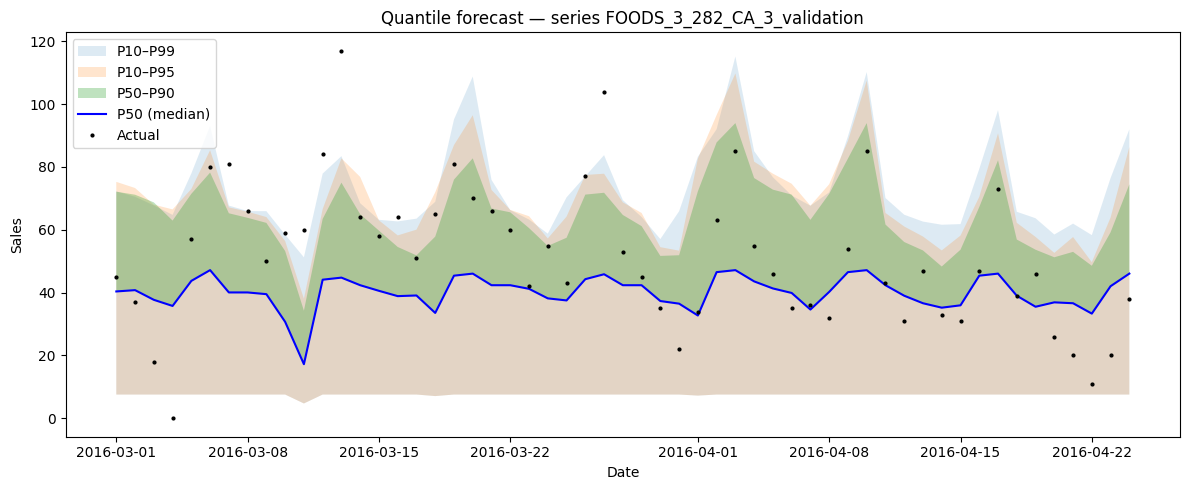

In [7]:
# Pick a high-volume series for visualisation
sample_id = test.groupby("id")["sales"].mean().idxmax()
sample = qpred_test[qpred_test["id"] == sample_id].sort_values("date")

fig, ax = plt.subplots(figsize=(12, 5))
ax.fill_between(sample["date"], sample["q10"], sample["q99"], alpha=0.15, label="P10–P99")
ax.fill_between(sample["date"], sample["q10"], sample["q95"], alpha=0.20, label="P10–P95")
ax.fill_between(sample["date"], sample["q50"], sample["q90"], alpha=0.30, label="P50–P90")
ax.plot(sample["date"], sample["q50"], "b-", lw=1.5, label="P50 (median)")
ax.plot(sample["date"], sample["sales"], "k.", markersize=4, label="Actual")
ax.set_title(f"Quantile forecast — series {sample_id}")
ax.set_xlabel("Date"); ax.set_ylabel("Sales")
ax.legend(); plt.tight_layout(); plt.show()